In [1]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using Bessels
using PyPlot
using Tullio
using DelimitedFiles
⊗(A,B) = kron(A,B)

⊗ (generic function with 1 method)

In [30]:
##### 
#Initial parameters 
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1]) 
σ_x =  Matrix{ComplexF64}([0 1; 1 0]) 
σ_y =  Matrix{ComplexF64}([0 -im ; im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])

ny = 3
nx = 3
nσ = 2 ;

In [31]:
GL = GreenFunction(zeros(ComplexF64, ny*nx*nσ, ny*nx*nσ, 1, 1), SkewHermitian)
GG = GreenFunction(zeros(ComplexF64, ny*nx*nσ, ny*nx*nσ, 1, 1), SkewHermitian);

In [32]:
# Auxiliary integrator for the first type of integral
function integrate0(t1,t2,A)
    retval = 0.0 + 0.0im
    dt = 0.01
    ts = t2:dt:t1
    A_vec = A.(ts)
    @tullio retval = A_vec[α]
    retval = retval*dt
end
function integrate1(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k] - B[t1, k], C[k, t2], hs[k], 1.0)
    end
    return retval
end
# Auxiliary integrator for the second type of integral
function integrate2(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t2)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k], B[k, t2] - C[k, t2], hs[k], 1.0)
    end
    return retval
end

integrate2 (generic function with 1 method)

In [33]:
Base.@kwdef struct DataFermiOrb{T}
    GL::T
    GG::T
    ΣL::T # zero(GL)
    ΣG::T # zero(GG)
    ###Ht::T
end

In [34]:
#### Auxiliary structure with the parameters of the model 
Base.@kwdef struct ModelParams{T1,T2}
    # interaction strength
    # Time dependence of the self energies
    Δ1::T1
    Δ2::T2
    γ::Float64
    γso::Float64
    Bz::Float64
    ny::Int
    nx::Int
    H::Array{ComplexF64,2}
    
end

### Self energy 


In [35]:
function Selfenergy(;E,H0l,H1l,Hlc,eta, epsilon=1e-10)
    "Calculation of the selfenergy. 
    The parameters needed are
    H0L : Supercell
    HLC: Matrix connecting the central system with the leads
    H1L : Hopping between super cells"
    one = Diagonal(ones(size(H0l)[1]))
    A0 = H1l'
    B0 = H1l
    C0 = (E + 1im*eta)*one - H0l
    D0 = (E +1im*eta)*one - H0l
    invD0 = inv(D0)
    while norm(A0) > epsilon
        #println(1)
        C = C0 - A0*invD0*B0
        D = D0 - A0*invD0*B0 - B0*invD0*A0
        A = A0*invD0*A0
        B = B0*invD0*B0
        ###################################
        A0 = A
        B0 = B
        C0 = C
        D0 = D
        invD0 =inv(D0)
    end
    g_L = inv(C0) ### Surface green function of the lead 
    Self = Hlc'*g_L*Hlc
end
### Block Hamiltonian 
function Block_H(γ,γso,Bz,ny)
    dim = ny*2 # We include the spin degree of freedom 
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' -Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end
### Central Hamiltonian
function Central_H(γ,γso,Bz,nx,ny)
    dim = nx*ny*2
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = Block_H(γ,γso,Bz,ny)
    Tx = diagm( -1 =>  ones(nx-1))⊗T #, 1 =>  ones(nx-1))
    HC = (One_x⊗H0) +  Tx + Tx'
    return HC
end


Central_H (generic function with 1 method)

### Store and read Self energy 

In [36]:
γ,γso,Bz,ny,nx = 1,0,0,ny,nx
H0,T = Block_H(γ,γso,Bz,ny)
Γ_SM(E) = -2*imag(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8))
Es = -4.0:0.01:4.0
Gamma_file = open("./Gamma_data", "w+")
for E_i in Es
    writedlm( Gamma_file, transpose(vec(Γ_SM(E_i))), ' ')
end
close(Gamma_file)

In [27]:
data_G  = readdlm("./Gamma_data");
# Tensor_G = zeros(Float64, (length(Es),6,6))
# for (i,E_i) in enumerate(Es) 
#     #println(i)
#     Tensor_G[i,:,:] = reshape(data_G[i,:], (6,6))
# end
#data_G
#Γ_SM(1.1)

### Compute Self energy objects

In [10]:
function fermi_mu(ϵ; μ=0.0, Temp=300)
    KB = 8.6173324e-5           ### Bolzmann factor
    β=1/(KB*Temp)
   1/(1. + exp((ϵ-μ)*β)  )   #(KB*Temp
end
######################################################
function SelfL_S(t)
    dϵ = 0.01
    ϵs = -4γ:dϵ:4γ
    e = exp.(-1im*ϵs*t)
    f = fermi_mu.(ϵs)
    ΣS = zeros(ComplexF64,(ny*nσ,ny*nσ))
    ΣS_11 = sum(data_G[:,1] .* f .* e)
    ΣS_13 = sum(data_G[:,3] .* f .* e)
    idx_11 = [(i,i) for i in 1:ny*nσ]
    idx_13 = [(1,3),(1,4),(4,1),(3,1)]
    ΣS[CartesianIndex.(idx_11)] .= 1im*ΣS_11*dϵ/(2pi)
    ΣS[CartesianIndex.(idx_13)] .= 1im*ΣS_13*dϵ/(2pi)
    return ΣS
end
######################################################
function SelfG_S(t)
    dϵ = 0.01
    ϵs = -4γ:dϵ:4γ
    e = exp.(-1im*ϵs*t)
    f = -fermi_mu.(ϵs) .+ 1.0
    ΣS = zeros(ComplexF64,(ny*nσ,ny*nσ))
    ΣS_11 = sum(data_G[:,1] .* f .* e)
    ΣS_13 = sum(data_G[:,3] .* f .* e)
    idx_11 = [(i,i) for i in 1:ny*nσ]
    idx_13 = [(1,3),(1,4),(4,1),(3,1)]
    ΣS[CartesianIndex.(idx_11)] .= -1im*ΣS_11*dϵ/(2pi)
    ΣS[CartesianIndex.(idx_13)] .= -1im*ΣS_13*dϵ/(2pi)
    return ΣS
end
function SelfL_L(t;γ=1,γc=1.)
    ΣL_L = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣL_S = SelfL_S(t)
    ΣL_L[1:ny*nσ,1:ny*nσ] = ΣL_S
    return ΣL_L
end
function SelfL_R(t;γ=1,γc=1.)
    ΣL_R = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣL_S = SelfL_S(t)
    ΣL_R[end-ny*nσ+1:end,end-ny*nσ+1:end] = ΣL_S
    return ΣL_R
end
function SelfL_T(t;γ=1,γc=1.)
    ΣL_T = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣL_S = SelfL_S(t)
    ΣL_T[end-ny*nσ+1:end,end-ny*nσ+1:end] = ΣL_S
    ΣL_T[1:ny*nσ,1:ny*nσ] = ΣL_S
    return ΣL_T
end
######################################################
function SelfG_L(t;γ=1,γc=1.)
    ΣG_L = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣG_S = SelfG_S(t)
    ΣG_L[1:ny*nσ,1:ny*nσ] = ΣG_S
    return ΣG_L
end
function SelfG_R(t;γ=1,γc=1.)
    ΣG_R = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣG_S = SelfG_S(t)
    ΣG_R[end-ny*nσ+1:end,end-ny*nσ+1:end] = ΣG_S
    return ΣG_R
end
function SelfG_T(t;γ=1,γc=1.)
    ΣG_T = zeros(ComplexF64,(nx*ny*nσ,nx*ny*nσ))
    ΣG_S = SelfG_S(t)
    ΣG_T[end-ny*nσ+1:end,end-ny*nσ+1:end] = ΣG_S
    ΣG_T[1:ny*nσ,1:ny*nσ] = ΣG_S
    return ΣG_T
end
stepp(t;ti=10) = t < ti ? sin((pi/2)*t/ti)^2 : 1
stepp2(t;ti=3,to=25) = 1/(1+exp(-(t-to)/ti))

stepp2 (generic function with 1 method)

In [11]:
function self_Lead!(model,data,times,_,_,t,t′)
    # Unpack data and model 
    (;GL,GG,ΣL,ΣG) = data
    (;Δ1, Δ2) = model
    ∫ds(A) = integrate0(times[t],times[t′], A  ) #### This integral should be modified!! to do it with inbounds
    # Resize self energies 
    if (n = size(GL,3)) > size(ΣL,3)
        resize!(ΣL, n)
        resize!(ΣG, n)
    end
    D2 = Matrix{ComplexF64}(I, nσ, nσ)
    ### Time dependece of the leads 
    ϕ1_t = ∫ds(Δ1)
    ϕ2_t = ∫ds(Δ2)
    dim = nx*ny*nσ
    ### Setting the component of the left self-energy
    selfL0 = zeros(ComplexF64,(dim,dim))
    selfG0 = zeros(ComplexF64, (dim,dim))
    #### Surface GF
    selfL_S = SelfL_S(times[t] - times[t′])
    selfG_S = SelfG_S(times[t] - times[t′])

    selfL0[1:ny*nσ,1:ny*nσ] = selfL_S*exp(-1im*ϕ1_t)
    selfL0[end-ny*nσ+1:end,end-ny*nσ+1:end] = selfL_S*exp(-1im*ϕ2_t)
    
    selfG0[1:ny*nσ,1:ny*nσ] = selfG_S*exp(-1im*ϕ1_t)
    selfG0[end-ny*nσ+1:end,end-ny*nσ+1:end] = selfG_S*exp(-1im*ϕ2_t)
    #########-------------------------------------------------------------------------------############
    ### Define the self energies 
    ΣL[t, t′] = selfL0*stepp2.(times[t];ti=1,to=15)*stepp2.(times[t′];ti=1,to=15)#exp()
    ΣG[t, t′] = selfG0*stepp2.(times[t];ti=1,to=15)*stepp2.(times[t′];ti=1,to=15)
end

self_Lead! (generic function with 1 method)

### Initial parameters 

In [12]:
#### Initial values
U₀ = 0.05
U₁ = 0.0 #0.05
γ,γso,Bz,ny,nx = 1.0,0.0,0.0,2,3
dim = nx*ny*nσ
H0 = Central_H(γ,γso,Bz,ny,nx)
model = ModelParams(Δ1 = t1-> U₀ ,Δ2 = t2-> U₁,γ=γ, γso=γso, Bz=Bz, ny=ny, nx=nx, H=H0)
#model = ModelParams(Δ1 = t1-> U₀ ,Δ2 = t2-> U₁,γ=1.0, γso=0.0, Bz=0.0,ny=3,nx=3,H=H0)#,γ=1.0, γso=0.0, Bz=0.0, ny=3, nx=3, H=H0)
N = ones(dim)*0.1
GL[1, 1] = 1.0im * diagm(N) #Gls_ij # 1.0im * diagm(N)#
GG[1, 1] = -1.0im*I(dim) + GL[1, 1]#Gls_ij#-1.0im * (I - diagm(N)) ; #
ΣL = zero(GL)
ΣG = zero(GG)
# Dig = Matrix{ComplexF64}(I, L*nσ, L*nσ)
ΣL[1,1] = SelfL_T(0.0)*0.0
ΣG[1,1] = SelfG_T(0.0)*0.0
data = DataFermiOrb(GL=GL, GG=GG, ΣL=ΣL, ΣG=ΣG) ;

### Eoms

In [13]:
function fv!(model, data, out, times, h1, h2, t, t′)
    # Unpack data and model
    (; GL, GG, ΣL, ΣG) = data
    (; Δ1, Δ2, H) = model ### How to modify the Hamiltonian to include the time dependence 
    # Real-time collision integrals
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
    # Equations of motion
    out[1] = -1.0im * ( H* GL[t, t′] +
        ∫dt1(ΣG, ΣL, GL) + ∫dt2(ΣL, GL, GG)) #### For G<
    out[2] = -1.0im * (H* GG[t, t′] +
        ∫dt1(ΣG, ΣL, GG) + ∫dt2(ΣG, GL, GG)) #### For G>
    return out
end

function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out[1] .-= out[1]'
    out[2] .-= out[2]'
end

fd! (generic function with 1 method)

### Evolution 

In [14]:
tmax = 50#80#30#120#120#20#100#80

# tolerances
atol = 1e-6#1e-8#1e-7#5
rtol = 1e-5#1e-6#1e-4#4

# Call the solver
elapsed_time = @elapsed begin
sol = kbsolve!(
    (x...) -> fv!(model, data, x...),
    (x...) -> fd!(model, data, x...),
    [data.GL, data.GG],
    (0.0, tmax);
    callback = (x...) -> self_Lead!(model, data, x...),
    atol = atol,
    rtol = rtol,
    stop = x -> (println("time : $(x[end])"); flush(stdout); false)
)
end
println("Total time of simulation: ", elapsed_time, " s" )

time : 0.0
time : 1.0e-6
time : 5.999999999999999e-6
time : 3.0999999999999995e-5
time : 0.00015599999999999997
time : 0.0007809999999999998
time : 0.0013434999999999996
time : 0.004155999999999998
time : 0.01821849999999999
time : 0.030874749999999986
time : 0.09415599999999996
time : 0.39762337886193916
time : 0.39762337886193916
time : 0.39762337886193916
time : 0.39762337886193916
time : 0.53228401523576
time : 0.6534785879721987
time : 0.7653363494942822
time : 0.8957063624654757
time : 1.0467468741000705
time : 1.219913521602362
time : 1.3757635043544243
time : 1.5310394450872802
time : 1.7000124738605273
time : 1.8617575294192614
time : 2.0237911359913205
time : 2.198111975374848
time : 2.368582054159495
time : 2.546852519576287
time : 2.731518030628603
time : 2.91137211982811
time : 3.103482797257246
time : 3.276382406943468
time : 3.444817233898558
time : 3.6184847355632397
time : 3.7874095351755614
time : 3.9496991671015116
time : 4.109029223495094
time : 4.263484359714999
ti

## Observables

In [25]:
cd = []
for j in 1:2:nx*ny*nσ
    cdj = [imag(diag(GL[t, t]))[j] + imag(diag(GL[t, t]))[j+1] for t in eachindex(sol.t)]
    push!(cd,cdj)
end

In [26]:
function PI1(hs::Vector, t1, A::GreenFunction, B::GreenFunction)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:t1
        @views LinearAlgebra.mul!(retval, A[t1, k] , B[k, t1], hs[k], 1.0)
    end
    return retval
end
∫dss(t,A, B) = PI1(sol.w[t], t, A, B)

∫dss (generic function with 1 method)

In [28]:
tss = 1:1:length(sol.t)
size_t = length(tss)
Σ0L_left = zeros(ComplexF64,ny*nσ*nx,ny*nσ*nx,size_t,size_t) 
Σ0L_right = zeros(ComplexF64,ny*nσ*nx,ny*nσ*nx,size_t,size_t) 
Σ0L_left[1:ny*nσ,1:ny*nσ,:,:]=ΣL[1:ny*nσ,1:ny*nσ,:,:] 
Σ0L_right[end-ny*nσ+1:end,end-ny*nσ+1:end,:,:]=ΣL[end-ny*nσ+1:end,end-ny*nσ+1:end,:,:] 
ΣL_left = GreenFunction(Σ0L_left, SkewHermitian)
ΣL_right = GreenFunction(Σ0L_right, SkewHermitian)

Σ0G_left = zeros(ComplexF64,ny*nσ*nx,ny*nσ*nx,size_t,size_t) 
Σ0G_right = zeros(ComplexF64,ny*nσ*nx,ny*nσ*nx,size_t,size_t) 
Σ0G_left[1:ny*nσ,1:ny*nσ,:,:]=ΣG[1:ny*nσ,1:ny*nσ,:,:] 
Σ0G_right[end-ny*nσ+1:end,end-ny*nσ+1:end,:,:]=ΣG[end-ny*nσ+1:end,end-ny*nσ+1:end,:,:] 
ΣG_left = GreenFunction(Σ0G_left, SkewHermitian)
ΣG_right = GreenFunction(Σ0G_right, SkewHermitian);

In [29]:
Π_left(t) = ∫dss(t,GG, ΣL_left)- ∫dss(t,GL, ΣG_left)
Π_right(t) = ∫dss(t,GG, ΣL_right)- ∫dss(t,GL, ΣG_right)

Π_right (generic function with 1 method)

In [30]:
#GG

In [31]:
Curr_left= real(tr.(Π_left.(tss)))
Curr_right= real(tr.(Π_right.(tss)));

In [36]:
cc = [4pi*Curr_left 4pi*Curr_right];

## Figures

In [37]:
using PyPlot
using DelimitedFiles
#const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text
fs = 25

25

## Charge density

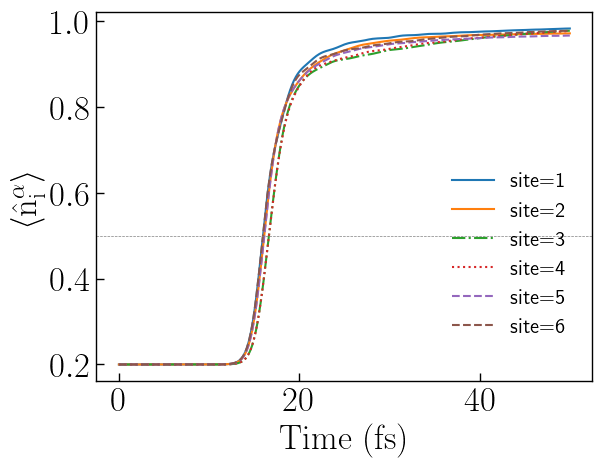

PyObject <matplotlib.lines.Line2D object at 0x7f1831f36c30>

In [38]:
fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,6)
axs.plot(sol.t, cd[1],label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current
axs.plot(sol.t, cd[2],label= "site=$(2)")
axs.plot(sol.t, cd[3],label= "site=$(3)",ls = "-.")
axs.plot(sol.t, cd[4],label= "site=$(4)",ls = ":")
axs.plot(sol.t, cd[5],label= "site=$(5)",ls="--")
axs.plot(sol.t, cd[6],label= "site=$(6)",ls="--")
axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(100,120)
plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)

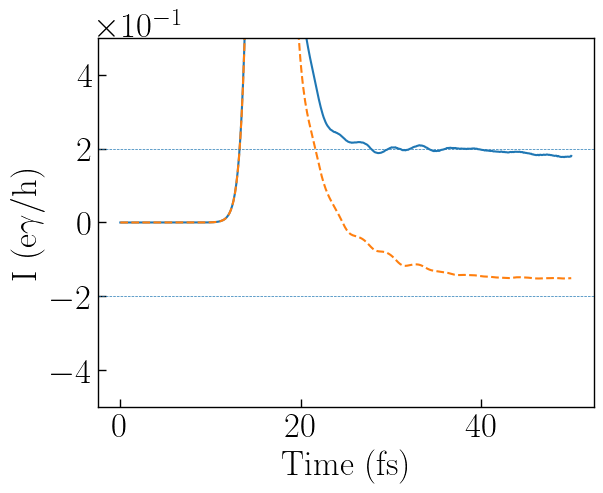

In [53]:
fig,axs = plt.subplots(1,1)

plt.plot(sol.t, cc[:,1])
plt.plot(sol.t, cc[:,2],ls = "--")
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.xlim(30,80)
plt.axhline(0.2,ls = "--",lw=0.5)
plt.axhline(-0.2,ls = "--",lw=0.5)
#plt.axhline(0.0,ls = "--",lw=0.5)
#plt.axhline(0.013,ls = "--",lw=0.5)
plt.ylim(-0.5,0.5)
plt.show()

In [52]:
### Integral expression for the seld energy
0.2/0.05

4.0

## Tests

In [ ]:
γ,γso,Bz,ny,nx = 1,0,0,3,1
H0,T = Block_H(γ,γso,Bz,ny)
Γ_SM(E) = -2*imag(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8))
Es = -5:0.01:5
Gamma_file = open("./Gamma_data", "w+")
for E_i in Es
    writedlm( Gamma_file, transpose(vec(Γ_SM(E_i))), ' ')
end
close(Gamma_file)
data_G  = readdlm("./Gamma_data");

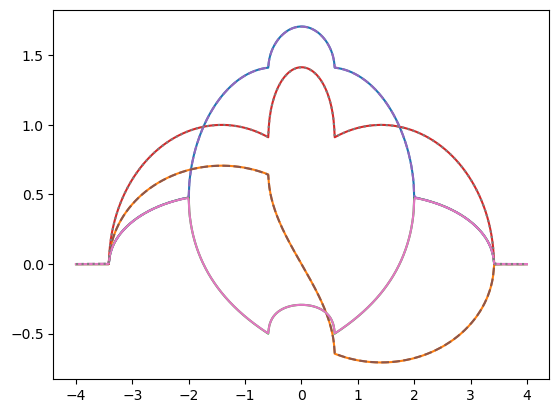

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f7dfa56d670>

In [73]:
function gr_n(ϵ;n,γ=1.,γc=1.,Ny=5)
    """ Retarded GF in the diagonal transverse basis chanel 
    """
    ϵ_n = -2*γ*cos(n*pi/(Ny+1))
    Δ = 4 * γ^2 - (ϵ - ϵ_n)^2
    if real(Δ) > 0
        Σ = ϵ - ϵ_n - im*sqrt(Δ)
    else
        if real(ϵ - ϵ_n) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ  = ϵ-ϵ_n - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
#### Components of the Gamma function 
function Γ_ij(ϵ;i,j,γ=1.,γc=1.,Ny=5)
    Γ(ϵ,n) = -2*imag(gr_n(ϵ;n=n,γ=γ,γc=γc,Ny=Ny))
    U_in(i,n) = sin(n*i*pi/(Ny+1))*sqrt(2/(Ny+1))
    res = 0.0
    for n_s in 1:Ny
        res += U_in(i,n_s)*Γ(ϵ,n_s)*U_in(j,n_s)
    end
    return res
end
ϵs = Es
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=1,Ny=3) )
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=2,Ny=3))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=3,Ny=3))

plt.plot(ϵs,Γ_ij.(ϵs;i=2,j=2,Ny=3) )

plt.plot(Es,data_G[:,1],label ="1" ,ls = "--")

plt.plot(Es,data_G[:,3],label ="2",ls = "--")

plt.plot(Es,data_G[:,5],label ="3")
 plt.plot(Es,data_G[:,15],label ="1",ls=":")

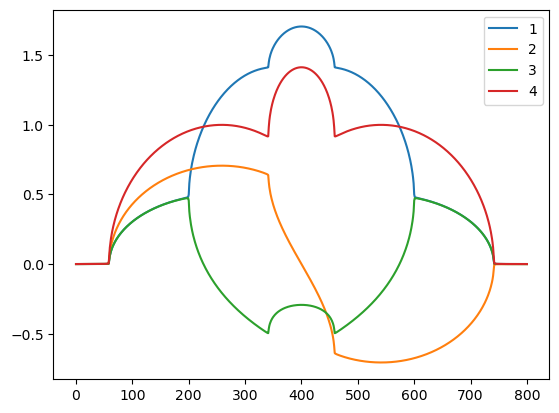

PyObject <matplotlib.legend.Legend object at 0x7f7dfc4e16a0>

In [40]:
plt.plot(data_G[:,1],label ="1")
#plt.plot(data_G[:,2],label="0.0")
plt.plot(data_G[:,3],label ="2")
#plt.plot(data_G[:,4],label="0.0")
plt.plot(data_G[:,5],label ="3")
# plt.plot(data_G[:,6],label="0.0")
# plt.plot(data_G[:,7],label="0.0")
# plt.plot(data_G[:,8],label ="1",ls=":")
# plt.plot(data_G[:,9],label="0.0")
# plt.plot(data_G[:,10],label ="2",ls="--")
# plt.plot(data_G[:,11],label="0.0")
# plt.plot(data_G[:,12],label="3")
plt.plot(data_G[:,15],label ="4")
#plt.plot(data_G[:,29],label ="3")
plt.legend()
### Note that due to symmetries in the self energies they can be integrated easily 

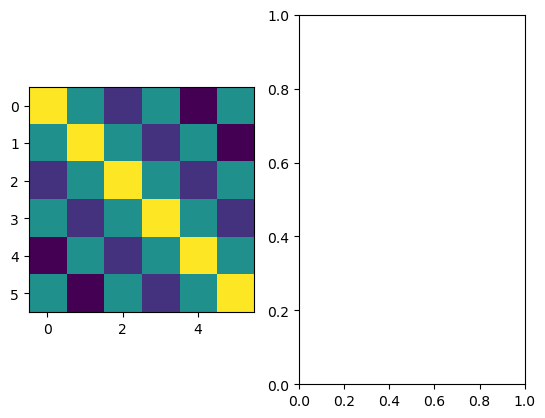

PyObject <matplotlib.image.AxesImage object at 0x7f7dfe113800>

In [28]:
fig,axs = plt.subplots(1,2)
#xmin,x_max,y_min,y_max=-
axs[1].imshow(-2*imag(Selfenergy(;E=0.1,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)),vmin=-0.1,vmax=0.1)
#axs[2].imshow(real(Selfenergy(;E=0.1,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)),vmin=-0.1,vmax=0.1)#, extent=[x_min, x_max, y_min, y_max]

In [ ]:
###Integral calculation 
function Σ_int(m,N_k);
    Nks = 1:N_p 
    for m in N_k
        for n in Nk
    2/(N+1)*sin(pi*m*Nk/(N+1))
end

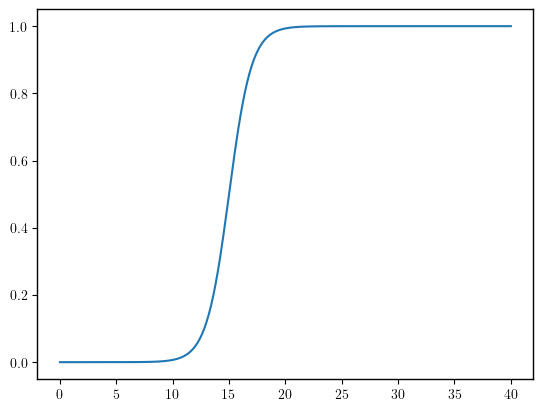

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f70e3b83770>

In [29]:

# H0,T = Block_H(γ,γso,Bz,ny)
# S1(E)=real(tr(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)))
# S2(E)=imag(tr(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)))
# self11(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[1,1]
# self22(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[2,2]
# self33(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[3,3]
# self44(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[4,4]
# self55(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[5,5]
# self66(E)= Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-3, epsilon=1e-8)[1,4]
#reshape(vec(Γ_SM(0.1)),(6,6)) == Γ_SM(0.1)
    # ΣS_33 = sum(data_G[:,15] .* f .*e)
    # ΣS_13 = sum(data_G[:,3] .* f .* e)
    # ΣS_15 = sum(data_G[:,5] .* f .* e)
    # idx_11 = [(1,1),(2,2),(5,5),(6,6)]
    # idx_33 = [(3,3),(4,4)]
    # idx_13 = [(1,3),(2,4),(3,5),(4,6),
    #           (3,1),(4,2),(5,3),(6,4)]
    # idx_15 = [(1,5),(2,6),
    #           (5,1),(6,2)]
ts = 0.0:0.1:40
# #plt.plot(ts,stepp.(ts;ti=50))
plt.plot(ts,stepp2.(ts;ti=1,to=15))
#plt.imshow(real.(SelfG_T(0.1)),vmin=-0.1,vmax=0.1)
#SelfL_T(0.1)